    engine_size  mileage  age fuel_type transmission  resale_price
0           1.2  45000.0  5.0    Petrol       Manual       2200000
1           1.5  30000.0  3.0    Diesel    Automatic       3000000
2           2.0  20000.0  2.0    Petrol    Automatic       4500000
3           NaN  60000.0  7.0    Hybrid    Automatic       2700000
4           1.8      NaN  4.0    Petrol       Manual       3500000
5           1.3  50000.0  NaN    Diesel       Manual       2100000
6           2.5  15000.0  1.0    Hybrid    Automatic       5200000
7           1.6  35000.0  3.0    Petrol       Manual       2800000
8           2.0  25000.0  2.0       NaN    Automatic       4000000
9           1.4  55000.0  6.0    Diesel          NaN       2300000
10          1.8  40000.0  4.0    Petrol       Manual       3100000
11          2.2  18000.0  2.0    Hybrid    Automatic       4800000
12          NaN  70000.0  8.0    Diesel       Manual       1800000
13          1.5  32000.0  3.0    Petrol    Automatic       290

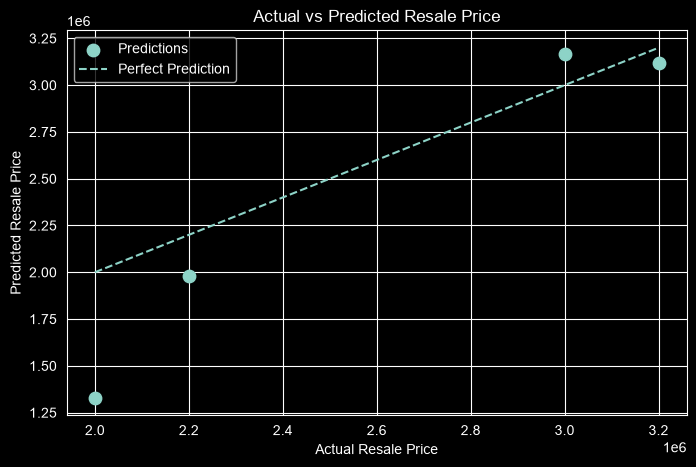

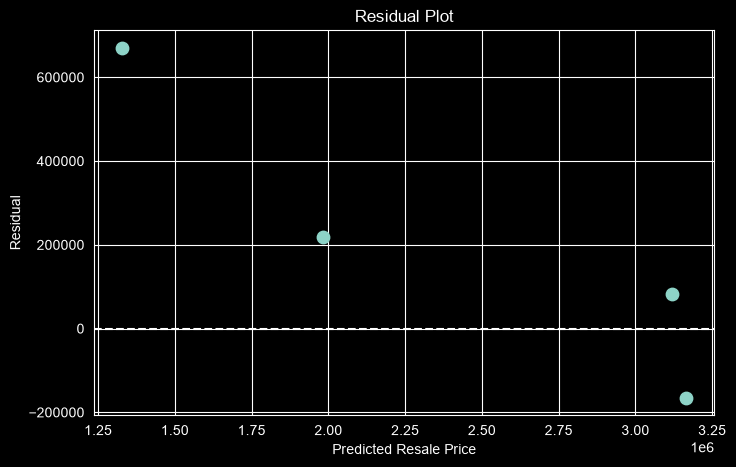


5-FOLD CROSS VALIDATION
Fold Scores:
[0.95450941 0.97058719 0.9732911  0.8857476  0.92680869]

Mean CV R²:
0.9421888003672839

Standard Deviation:
0.03270405361872593


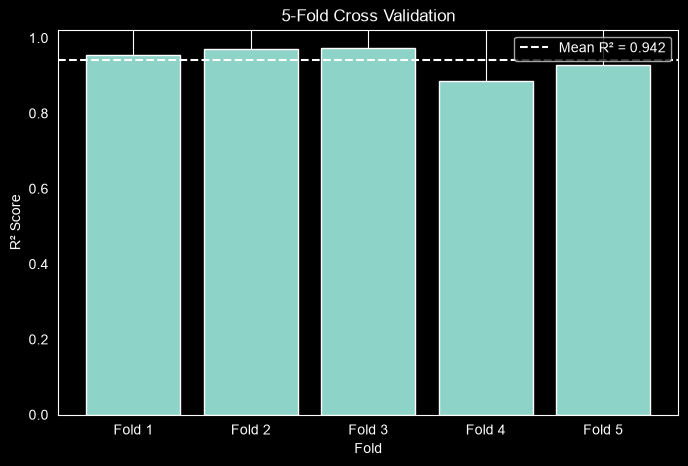

In [3]:
# ==========================================
# 1. IMPORT LIBRARIES
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import Ridge

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)


# ==========================================
# 2. CREATE DATASET
# ==========================================

data = {
    "engine_size": [
        1.2, 1.5, 2.0, np.nan, 1.8,
        1.3, 2.5, 1.6, 2.0, 1.4,
        1.8, 2.2, np.nan, 1.5, 2.0,
        1.3, 2.4, 1.7, 1.5, 2.0
    ],

    "mileage": [
        45000, 30000, 20000, 60000, np.nan,
        50000, 15000, 35000, 25000, 55000,
        40000, 18000, 70000, 32000, 22000,
        65000, 12000, np.nan, 45000, 28000
    ],

    "age": [
        5, 3, 2, 7, 4,
        np.nan, 1, 3, 2, 6,
        4, 2, 8, 3, 2,
        7, 1, 5, np.nan, 3
    ],

    "fuel_type": [
        "Petrol", "Diesel", "Petrol", "Hybrid",
        "Petrol", "Diesel", "Hybrid", "Petrol",
        np.nan, "Diesel", "Petrol", "Hybrid",
        "Diesel", "Petrol", "Hybrid", "Diesel",
        "Petrol", "Hybrid", "Diesel", "Petrol"
    ],

    "transmission": [
        "Manual", "Automatic", "Automatic", "Automatic",
        "Manual", "Manual", "Automatic", "Manual",
        "Automatic", np.nan, "Manual", "Automatic",
        "Manual", "Automatic", "Automatic", "Manual",
        "Automatic", "Manual", "Automatic", "Manual"
    ],

    "resale_price": [
        2200000, 3000000, 4500000, 2700000, 3500000,
        2100000, 5200000, 2800000, 4000000, 2300000,
        3100000, 4800000, 1800000, 2900000, 4300000,
        2000000, 5500000, 3200000, 2600000, 3900000
    ]
}

df = pd.DataFrame(data)

print(df)


# ==========================================
# 3. X AND Y
# ==========================================

X = df.drop("resale_price", axis=1)

Y = df["resale_price"]


# ==========================================
# 4. TRAIN / TEST SPLIT
# ==========================================

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("Y_train:", Y_train.shape)
print("Y_test :", Y_test.shape)


# ==========================================
# 5. FEATURE TYPES
# ==========================================

numeric_features = [
    "engine_size",
    "mileage",
    "age"
]

categorical_features = [
    "fuel_type",
    "transmission"
]


# ==========================================
# 6. NUMERICAL PIPELINE
# ==========================================

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


# ==========================================
# 7. CATEGORICAL PIPELINE
# ==========================================

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])


# ==========================================
# 8. COLUMN TRANSFORMER
# ==========================================

preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        numeric_features
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features
    )
])


# ==========================================
# 9. RIDGE PIPELINE
# ==========================================

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", Ridge(alpha=1.0))
])


# ==========================================
# 10. TRAIN MODEL
# ==========================================

model.fit(
    X_train,
    Y_train
)

print("Model trained successfully!")


# ==========================================
# 11. PREDICTIONS
# ==========================================

predictions = model.predict(X_test)

print("\nPredictions:")
print(predictions)


# ==========================================
# 12. ACTUAL VS PREDICTED
# ==========================================

comparison = pd.DataFrame({
    "Actual": Y_test.values,
    "Predicted": predictions
})

print("\nActual vs Predicted:")
print(comparison)


# ==========================================
# 13. MODEL EVALUATION
# ==========================================

r2 = r2_score(
    Y_test,
    predictions
)

mae = mean_absolute_error(
    Y_test,
    predictions
)

mse = mean_squared_error(
    Y_test,
    predictions
)

rmse = np.sqrt(mse)

print("\n==========================")
print("MODEL EVALUATION")
print("==========================")

print("R²   :", r2)
print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)


# ==========================================
# 14. RESIDUALS
# ==========================================

comparison["Residual"] = (
    comparison["Actual"] -
    comparison["Predicted"]
)

print("\nResiduals:")
print(comparison)


# ==========================================
# 15. ACTUAL VS PREDICTED GRAPH
# ==========================================

plt.figure(figsize=(8, 5))

plt.scatter(
    comparison["Actual"],
    comparison["Predicted"],
    s=80,
    label="Predictions"
)

minimum = comparison["Actual"].min()
maximum = comparison["Actual"].max()

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--",
    label="Perfect Prediction"
)

plt.xlabel("Actual Resale Price")
plt.ylabel("Predicted Resale Price")

plt.title("Actual vs Predicted Resale Price")

plt.legend()
plt.grid(True)

plt.show()


# ==========================================
# 16. RESIDUAL PLOT
# ==========================================

plt.figure(figsize=(8, 5))

plt.scatter(
    comparison["Predicted"],
    comparison["Residual"],
    s=80
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Resale Price")
plt.ylabel("Residual")

plt.title("Residual Plot")

plt.grid(True)

plt.show()


# ==========================================
# 17. CROSS VALIDATION
# ==========================================

cv_scores = cross_val_score(
    model,
    X,
    Y,
    cv=5,
    scoring="r2"
)

print("\n==========================")
print("5-FOLD CROSS VALIDATION")
print("==========================")

print("Fold Scores:")
print(cv_scores)

print("\nMean CV R²:")
print(cv_scores.mean())

print("\nStandard Deviation:")
print(cv_scores.std())


# ==========================================
# 18. CROSS VALIDATION GRAPH
# ==========================================

plt.figure(figsize=(8, 5))

plt.bar(
    ["Fold 1", "Fold 2", "Fold 3", "Fold 4", "Fold 5"],
    cv_scores
)

plt.axhline(
    cv_scores.mean(),
    linestyle="--",
    label=f"Mean R² = {cv_scores.mean():.3f}"
)

plt.xlabel("Fold")
plt.ylabel("R² Score")

plt.title("5-Fold Cross Validation")

plt.legend()
plt.grid(axis="y")

plt.show()

In [4]:
from sklearn.model_selection import GridSearchCV
model=Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", Ridge(alpha=1.0))

])

In [9]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "regressor__alpha": [0.01, 0.1, 1, 10, 100]
}

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring="r2"
)

grid_search.fit(X_train, Y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV R²:")
print(grid_search.best_score_)

Best Parameters:
{'regressor__alpha': 1}

Best CV R²:
0.9174519884447209


In [11]:

grid_search.fit(X_train, Y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV R²:")
print(grid_search.best_score_)

Best Parameters:
{'regressor__alpha': 1}

Best CV R²:
0.9174519884447209


In [14]:
best_model = grid_search.best_estimator_


In [16]:
best_predictions = best_model.predict(X_test)
print(best_predictions)


[1981798.61905927 3117555.53590904 1329496.71901757 3165166.05887163]


In [17]:
best_r2 = r2_score(
    Y_test,
    best_predictions
)

best_mae = mean_absolute_error(
    Y_test,
    best_predictions
)

best_mse = mean_squared_error(
    Y_test,
    best_predictions
)

best_rmse = np.sqrt(best_mse)

print("R²   :", best_r2)
print("MAE  :", best_mae)
print("MSE  :", best_mse)
print("RMSE :", best_rmse)

R²   : 0.4891697989278023
MAE  : 284078.7962214396
MSE  : 132815852278.7714
RMSE : 364439.0926873397


In [18]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "regressor__alpha": [0.01, 0.1, 1, 10, 100]
}

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring="r2"
)

grid_search.fit(X_train, Y_train)

print("Best Parameters:", grid_search.best_params_)
print("Beqst CV R²:", grid_search.best_score_)

Best Parameters: {'regressor__alpha': 1}
Best CV R²: 0.9174519884447209
